# Two-stage normal-TS candidates and synthetic exact verification

This experiment measures the recall of normal-tree-sequence interval candidates against the deterministic balanced synthetic/full-ARG exact-cone oracle. The exhaustive normal-breakpoint catalog is the correctness guarantee; topology tiers are diagnostics only.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=r"Pandas requires version .* of 'numexpr'")
    import pandas as pd
import tskit
from IPython.display import display


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start).expanduser().resolve()
    fallback = Path("/Users/pratik/Documents/work/aim3/simpliied")
    for candidate in (start, *start.parents, fallback):
        if (candidate / "arg/new_rl/exact_closed_cones.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the workspace root")


WORKSPACE_ROOT = find_workspace_root()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from arg.new_rl.exact_closed_cones import (
    DEFAULT_ADJACENCY_TIERS,
    evaluate_two_stage_exact_cones,
)

FIXTURE_PATHS = {
    "25 kb": WORKSPACE_ROOT / "arg/validation/output/tsinfer/l25kb_dated.trees",
    "1 Mb": WORKSPACE_ROOT / "arg/validation/output/tsinfer/l1mb_dated.trees",
}
for fixture_path in FIXTURE_PATHS.values():
    if not fixture_path.is_file():
        raise FileNotFoundError(fixture_path)

DEFAULT_ADJACENCY_TIERS

(1, 2, 4, 8, 16, 32)

## Run the two-stage equivalence oracle

The conversion is in memory. The exact all-cut scan is deliberately not candidate-directed in this milestone, so it is an independent oracle for candidate recall.

In [2]:
two_stage_evaluations = {
    label: evaluate_two_stage_exact_cones(path)
    for label, path in FIXTURE_PATHS.items()
}

normal_candidate_catalogs = {
    label: result.candidate_catalog
    for label, result in two_stage_evaluations.items()
}
exact_verified_cones = {
    label: result.exact_verified_cones
    for label, result in two_stage_evaluations.items()
}

{
    label: {
        "normal_breakpoints": len(result.candidate_catalog.breakpoints),
        "synthetic_events": result.trace.num_steps,
        "exact_verified_cones": len(result.exact_verified_cones),
        "exhaustive_recall": result.recall_by_tier["exhaustive"],
    }
    for label, result in two_stage_evaluations.items()
}

{'25 kb': {'normal_breakpoints': 10,
  'synthetic_events': 25,
  'exact_verified_cones': 5,
  'exhaustive_recall': 1.0},
 '1 Mb': {'normal_breakpoints': 413,
  'synthetic_events': 1801,
  'exact_verified_cones': 141,
  'exhaustive_recall': 1.0}}

In [3]:
candidate_metrics_df = pd.DataFrame(
    [
        {
            "fixture": label,
            "tier": tier,
            "candidate_count": result.candidate_count_by_tier[tier],
            "exact_cone_recall": result.recall_by_tier[tier],
            "missed_exact_cones": len(result.missed_intervals_by_tier[tier]),
        }
        for label, result in two_stage_evaluations.items()
        for tier in (*result.candidate_catalog.adjacency_tiers, "exhaustive")
    ]
)
display(candidate_metrics_df)

timings_df = pd.DataFrame(
    [dict(fixture=label, **result.timings)
     for label, result in two_stage_evaluations.items()]
)
display(timings_df)

,fixture,tier,candidate_count,exact_cone_recall,missed_exact_cones
0,25 kb,1,12,0.800000,1
1,25 kb,2,24,1.000000,0
2,25 kb,4,38,1.000000,0
3,25 kb,8,44,1.000000,0
4,25 kb,16,44,1.000000,0
5,25 kb,32,44,1.000000,0
6,25 kb,exhaustive,44,1.000000,0
7,1 Mb,1,658,0.687943,44
8,1 Mb,2,1404,0.886525,16
9,1 Mb,4,2952,0.978723,3


,fixture,candidate_generation_seconds,synthetic_conversion_seconds,trace_construction_seconds,exact_scan_seconds,total_seconds
0,25 kb,0.000972,0.000897,0.275547,0.013832,0.291248
1,1 Mb,3.200281,0.018536,0.000470,22.986194,26.205481


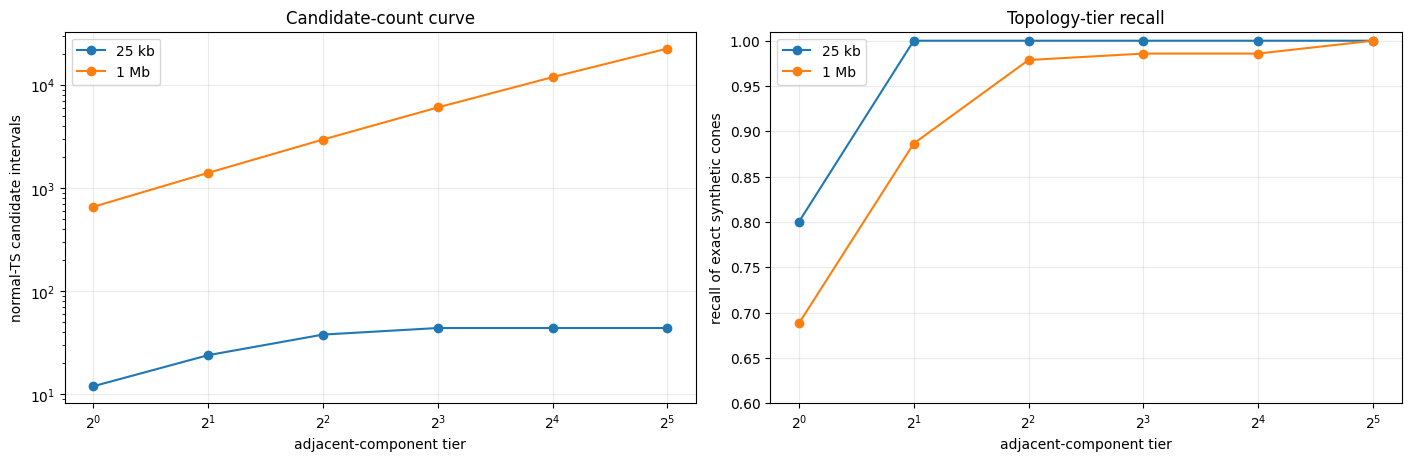

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for label, result in two_stage_evaluations.items():
    tiers = list(result.candidate_catalog.adjacency_tiers)
    axes[0].plot(
        tiers,
        [result.candidate_count_by_tier[tier] for tier in tiers],
        marker="o",
        label=label,
    )
    axes[1].plot(
        tiers,
        [result.recall_by_tier[tier] for tier in tiers],
        marker="o",
        label=label,
    )
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("adjacent-component tier")
axes[0].set_ylabel("normal-TS candidate intervals")
axes[0].set_title("Candidate-count curve")
axes[1].set_xscale("log", base=2)
axes[1].set_ylim(0.6, 1.01)
axes[1].set_xlabel("adjacent-component tier")
axes[1].set_ylabel("recall of exact synthetic cones")
axes[1].set_title("Topology-tier recall")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

## Exact cones and tier misses

In [5]:
def cone_summary_dataframe(cones):
    return pd.DataFrame(
        [
            {
                "cone_id": cone["cone_id"],
                "left": cone["left"],
                "right": cone["right"],
                "span": cone["span"],
                "first_cut_step": cone["first_closed_step"],
                "first_cut_time": cone["first_closed_time"],
                "last_cut_step": cone["last_closed_step"],
                "valid_cut_count": cone["valid_cut_count"],
                "events": cone["event_count"],
                "recombination_events": cone["recombination_event_count"],
                "coalescence_events": cone["coalescence_event_count"],
                "normal_smallest_tier": cone["normal_candidate_smallest_adjacency_tier"],
                "normal_exhaustive_only": cone["normal_candidate_exhaustive_only"],
            }
            for cone in cones
        ]
    )

exact_verified_cones_df = {
    label: cone_summary_dataframe(cones)
    for label, cones in exact_verified_cones.items()
}
for label, summary in exact_verified_cones_df.items():
    print(label)
    display(summary)

25 kb


,cone_id,left,right,span,first_cut_step,first_cut_time,last_cut_step,valid_cut_count,events,recombination_events,coalescence_events,normal_smallest_tier,normal_exhaustive_only
0,cone-0000,386.0,23963.0,23577.0,8,2949.117101,17,10,17,9,8,1,False
1,cone-0001,386.0,9543.0,9157.0,18,27617.469048,24,7,3,1,2,1,False
2,cone-0002,22242.0,23963.0,1721.0,18,27617.469048,21,4,4,2,2,2,False
3,cone-0003,22242.0,22880.0,638.0,22,38946.101470,22,1,1,0,1,1,False
4,cone-0004,22880.0,23963.0,1083.0,22,38946.101470,23,2,1,0,1,1,False


1 Mb


,cone_id,left,right,span,first_cut_step,first_cut_time,last_cut_step,valid_cut_count,events,recombination_events,coalescence_events,normal_smallest_tier,normal_exhaustive_only
0,cone-0000,892.0,999859.0,998967.0,11,100.864249,910,900,1790,1315,475,1,False
1,cone-0001,892.0,8149.0,7257.0,911,5487.792697,1624,714,6,1,5,1,False
2,cone-0002,8149.0,999859.0,991710.0,911,5487.792697,1010,100,884,531,353,32,False
3,cone-0003,8149.0,983355.0,975206.0,1011,6491.075694,1213,203,769,454,315,32,False
4,cone-0004,983355.0,999859.0,16504.0,1011,6491.075694,1360,350,17,9,8,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,cone-0136,353058.0,355785.0,2727.0,1742,39006.522441,1762,21,1,0,1,1,False
137,cone-0137,455080.0,462247.0,7167.0,1749,40438.215713,1790,42,1,0,1,1,False
138,cone-0138,482091.0,485496.0,3405.0,1749,40438.215713,1797,49,1,0,1,1,False
139,cone-0139,539207.0,545319.0,6112.0,1762,44060.023838,1798,37,1,0,1,1,False


In [6]:
missed_intervals_df = {
    label: pd.DataFrame(
        [
            {"tier": tier, "left": left, "right": right, "span": right - left}
            for tier, intervals in result.missed_intervals_by_tier.items()
            if tier != "exhaustive"
            for left, right in intervals
        ]
    )
    for label, result in two_stage_evaluations.items()
}
for label, missed in missed_intervals_df.items():
    print(label)
    display(missed)

25 kb


,tier,left,right,span
0,1,22242.0,23963.0,1721.0


1 Mb


,tier,left,right,span
0,1,8149.0,983355.0,975206.0
1,1,8149.0,999859.0,991710.0
2,1,98354.0,110932.0,12578.0
3,1,110932.0,126101.0,15169.0
4,1,134074.0,153474.0,19400.0
...,...,...,...,...
62,4,191322.0,238736.0,47414.0
63,8,8149.0,983355.0,975206.0
64,8,8149.0,999859.0,991710.0
65,16,8149.0,983355.0,975206.0


## Equivalence assertions

These checks make the normal-breakpoint exhaustive catalog the explicit 100% recall contract. A topology tier reaching 100% is reported as an empirical result for these fixtures, not a general proof.

In [7]:
expected_cone_counts = {"25 kb": 5, "1 Mb": 141}
for label, expected_count in expected_cone_counts.items():
    result = two_stage_evaluations[label]
    assert len(result.exact_verified_cones) == expected_count
    assert result.recall_by_tier["exhaustive"] == 1.0
    assert not result.missed_intervals_by_tier["exhaustive"]

assert two_stage_evaluations["25 kb"].recall_by_tier[2] == 1.0
assert two_stage_evaluations["1 Mb"].recall_by_tier[32] == 1.0
"Two-stage equivalence checks passed."

'Two-stage equivalence checks passed.'